# PE-AV — Gradient & Myelin Alignment (59k)

In [4]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import subprocess
from pathlib import Path
from scipy.stats import spearmanr

# ── Paths ──────────────────────────────────────────────────────────────────
OUTPUTS_BASE   = '/home/amin/Research/Representation/Movie/outputs'
DATA_BASE      = '/home/amin/Research/Representation/Movie/data'
HCP_DIR        = f'{DATA_BASE}/HCP_S1200_GroupAvg_v1'
TEMPLATE_CIFTI = f'{DATA_BASE}/preprocessed/average_sub/raw/group_average_raw_cortex_59k.dtseries.nii'
MYELIN_CIFTI   = f'{DATA_BASE}/HCP_S1200_GroupAvg_v1/S1200.SmoothedMyelinMap_BC_MSMAll.32k_fs_LR.dscalar.nii'
GRAD_DIR       = f'{DATA_BASE}/margulies2016'
WB             = '/opt/workbench/bin_linux64/wb_command'

SPHERE_32K = {
    'L': f'{HCP_DIR}/S1200.L.sphere.32k_fs_LR.surf.gii',
    'R': f'{HCP_DIR}/S1200.R.sphere.32k_fs_LR.surf.gii',
}
SPHERE_59K = {
    'L': f'{HCP_DIR}/L.sphere.59k_fs_LR.surf.gii',
    'R': f'{HCP_DIR}/R.sphere.59k_fs_LR.surf.gii',
}

BIN_TAG    = 'bin5s_skip5s'
CONFIG     = 'k100_delay5s'
MODALITIES = {'av': 'AV Joint', 'a': 'Audio', 'v': 'Video'}

GRADIENT_LABELS = {
    1:  'G1: Unimodal→Heteromodal',
    2:  'G2: Visual→Somatomotor',
    3:  'G3: DMN→FPN',
    4:  'G4: Dorsal→Ventral Attn',
    5:  'G5: Visual→Ventral Attn',
    6:  'G6: Default→Dorsal Attn',
    7:  'G7: Med.Par.→Lat.PFC',
    8:  'G8: Primary→Premotor',
    9:  'G9: Foveal→Peripheral',
    10: 'G10: Auditory→Somatosens.',
}

# ── Extract 59k CIFTI vertex indices ──────────────────────────────────────
bm_axis = nib.load(TEMPLATE_CIFTI).header.get_axis(1)
left_cifti_idx = right_cifti_idx = None
for name, _, model in bm_axis.iter_structures():
    if 'CORTEX_LEFT'  in name: left_cifti_idx  = model.vertex
    if 'CORTEX_RIGHT' in name: right_cifti_idx = model.vertex

n_left  = len(left_cifti_idx)
n_right = len(right_cifti_idx)
print(f"59k CIFTI: {n_left} L + {n_right} R = {n_left+n_right} grayordinates")

# ── Cache dir for resampled 32k→59k files (one-time cost) ─────────────────
CACHE_DIR = Path('/tmp/gradient_59k_cache')
CACHE_DIR.mkdir(exist_ok=True)

def _resample_to_59k(src_path, hemi, out_path):
    subprocess.run(
        [WB, '-metric-resample', str(src_path),
         SPHERE_32K[hemi], SPHERE_59K[hemi],
         'BARYCENTRIC', str(out_path)],
        check=True, capture_output=True
    )

def load_gradient_59k(grad_num):
    """Load Margulies gradient resampled to 59k, indexed to CIFTI grayordinates → (108441,)."""
    grad_str = f'0{grad_num}' if grad_num < 10 else '10'
    parts = []
    for hemi, cidx in [('L', left_cifti_idx), ('R', right_cifti_idx)]:
        cached = CACHE_DIR / f'grad{grad_str}_59k_{hemi}.func.gii'
        if not cached.exists():
            src = (f'{GRAD_DIR}/fcgradient{grad_str}/fsLR'
                   f'/source-margulies2016_desc-fcgradient{grad_str}'
                   f'_space-fsLR_den-32k_hemi-{hemi}_feature.func.gii')
            _resample_to_59k(src, hemi, cached)
        parts.append(nib.load(str(cached)).agg_data()[cidx])
    return np.concatenate(parts)

def load_myelin_59k():
    """Load SmoothedMyelinMap resampled to 59k, indexed to CIFTI grayordinates → (108441,)."""
    parts = []
    myelin_img  = nib.load(MYELIN_CIFTI)
    myelin_bm32 = myelin_img.header.get_axis(1)
    myelin_data = myelin_img.get_fdata().squeeze()  # (59412,)
    for hemi, cidx in [('L', left_cifti_idx), ('R', right_cifti_idx)]:
        cached_59k = CACHE_DIR / f'myelin_59k_{hemi}.func.gii'
        if not cached_59k.exists():
            tmp_32k = CACHE_DIR / f'myelin_32k_{hemi}.func.gii'
            full_arr = np.full(32492, np.nan, dtype=np.float32)
            for name, slc, mdl in myelin_bm32.iter_structures():
                if (hemi == 'L' and 'LEFT' in name) or (hemi == 'R' and 'RIGHT' in name):
                    full_arr[mdl.vertex] = myelin_data[slc].astype(np.float32)
                    break
            darray = nib.gifti.GiftiDataArray(
                data=full_arr,
                intent=nib.nifti1.intent_codes['NIFTI_INTENT_NONE'],
                datatype='NIFTI_TYPE_FLOAT32'
            )
            nib.save(nib.gifti.GiftiImage(darrays=[darray]), str(tmp_32k))
            _resample_to_59k(tmp_32k, hemi, cached_59k)
        parts.append(nib.load(str(cached_59k)).agg_data()[cidx])
    return np.concatenate(parts)

def load_rsa_maps(mod_code):
    """Return (grp_rho, persubj_mean_rho, persubj_cohens_d) each shape (108441,)."""
    grp_path = (f'{OUTPUTS_BASE}/rsa/raw/group_average/pe-av-small-16-frame_{mod_code}'
                f'/{CONFIG}_{BIN_TAG}_spearman'
                f'/rsa_59k_raw_{CONFIG}_{BIN_TAG}_spearman_searchlight.npy')
    grp_rho = np.load(grp_path)

    gs_path = (f'{OUTPUTS_BASE}/rsa/raw/group_stats/pe-av-small-16-frame_{mod_code}'
               f'/{CONFIG}_{BIN_TAG}_spearman/group_stats_175subs.dscalar.nii')
    gs_data = nib.load(gs_path).get_fdata()  # (6, 108441): mean_rho, cohens_d, ...
    return grp_rho, gs_data[0], gs_data[1]

print("Setup complete.")


59k CIFTI: 54216 L + 54225 R = 108441 grayordinates
Setup complete.


## Gradient Correlations

Loading/resampling gradients to 59k...
Done.



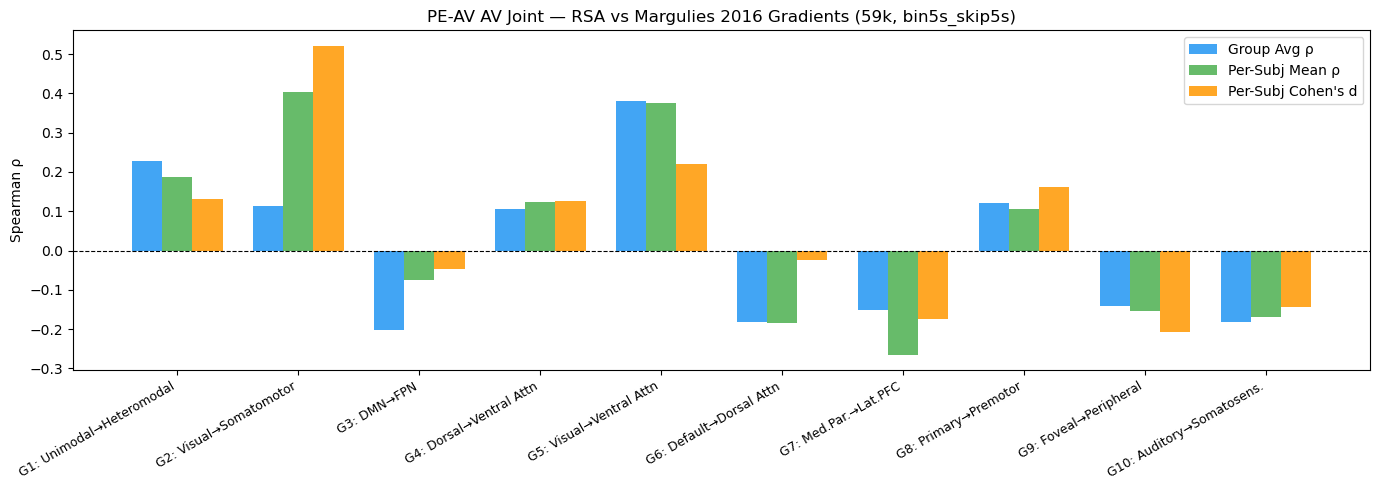

AV Joint:
  Group Avg ρ: G1=0.229  G2=0.114  G3=-0.202  G4=0.107  G5=0.382  G6=-0.181  G7=-0.151  G8=0.122  G9=-0.142  G10=-0.182
  Per-Subj Mean ρ: G1=0.186  G2=0.405  G3=-0.075  G4=0.124  G5=0.375  G6=-0.185  G7=-0.265  G8=0.106  G9=-0.153  G10=-0.170
  Per-Subj Cohen's d: G1=0.130  G2=0.521  G3=-0.047  G4=0.125  G5=0.220  G6=-0.025  G7=-0.174  G8=0.163  G9=-0.206  G10=-0.144



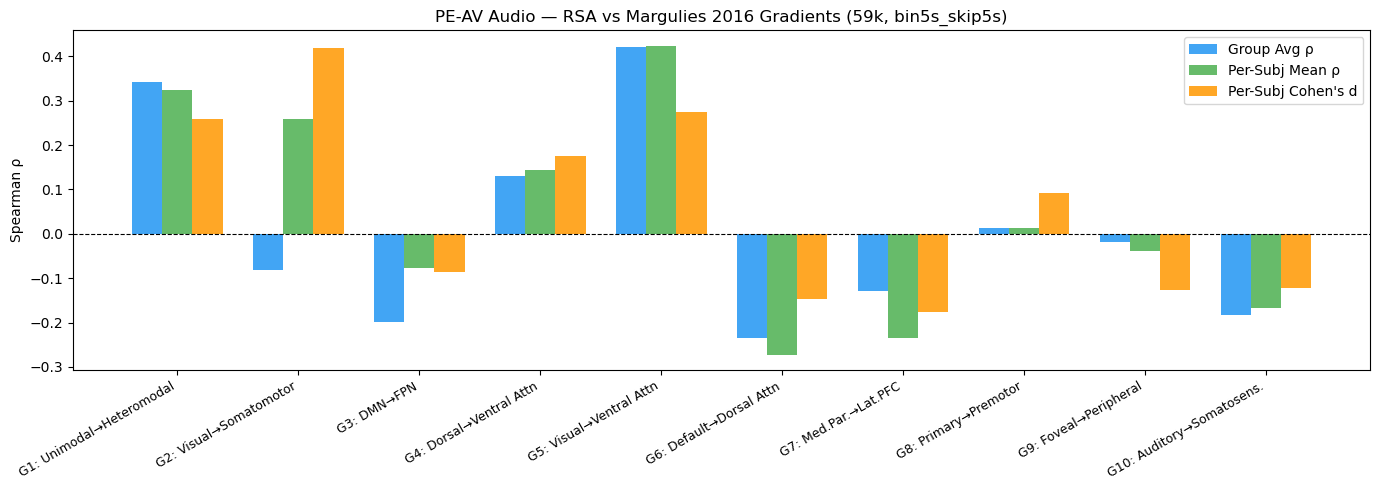

Audio:
  Group Avg ρ: G1=0.342  G2=-0.083  G3=-0.200  G4=0.130  G5=0.422  G6=-0.236  G7=-0.129  G8=0.012  G9=-0.019  G10=-0.182
  Per-Subj Mean ρ: G1=0.323  G2=0.260  G3=-0.078  G4=0.143  G5=0.424  G6=-0.272  G7=-0.235  G8=0.013  G9=-0.038  G10=-0.167
  Per-Subj Cohen's d: G1=0.259  G2=0.418  G3=-0.086  G4=0.176  G5=0.275  G6=-0.146  G7=-0.176  G8=0.091  G9=-0.126  G10=-0.122



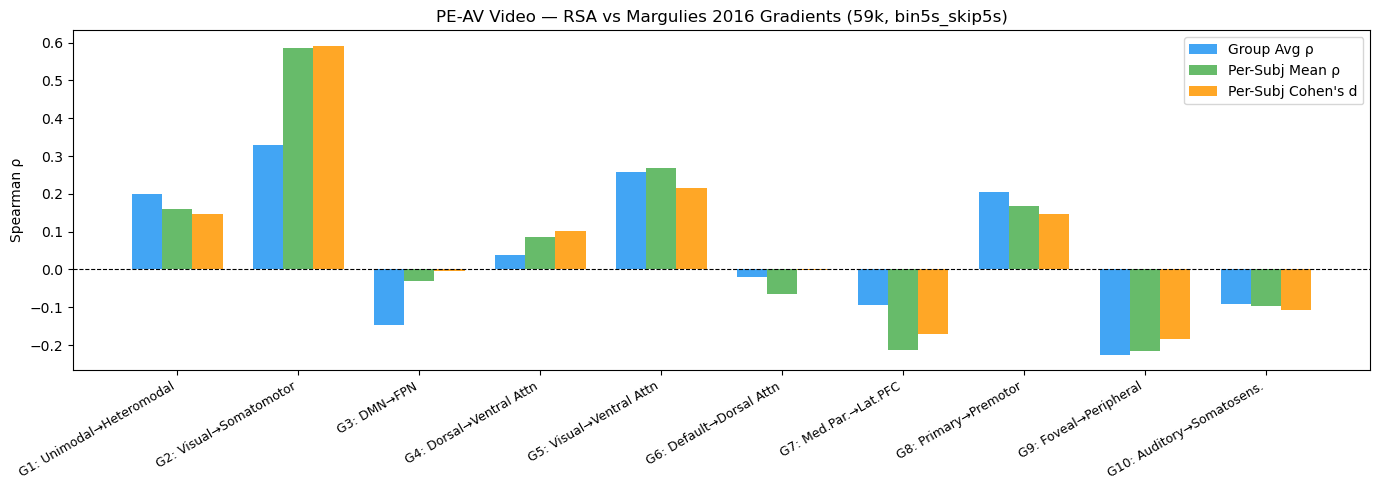

Video:
  Group Avg ρ: G1=0.199  G2=0.330  G3=-0.147  G4=0.037  G5=0.257  G6=-0.020  G7=-0.093  G8=0.206  G9=-0.225  G10=-0.092
  Per-Subj Mean ρ: G1=0.159  G2=0.587  G3=-0.031  G4=0.086  G5=0.269  G6=-0.065  G7=-0.213  G8=0.169  G9=-0.216  G10=-0.097
  Per-Subj Cohen's d: G1=0.147  G2=0.592  G3=-0.004  G4=0.101  G5=0.217  G6=-0.000  G7=-0.170  G8=0.146  G9=-0.185  G10=-0.107



In [2]:
# Resample all 10 Margulies gradients from 32k→59k (cached to /tmp after first run)
print("Loading/resampling gradients to 59k...")
gradients = {g: load_gradient_59k(g) for g in range(1, 11)}
print("Done.\n")

RSA_LABELS = ['Group Avg ρ', 'Per-Subj Mean ρ', "Per-Subj Cohen's d"]
COLORS     = ['#2196F3', '#4CAF50', '#FF9800']

for mod_code, mod_label in MODALITIES.items():
    grp_rho, ps_rho, ps_d = load_rsa_maps(mod_code)
    rsa_maps = [grp_rho, ps_rho, ps_d]

    # Compute Spearman r for each RSA type × gradient
    corrs = np.zeros((3, 10))
    for ri, rsa_map in enumerate(rsa_maps):
        for g in range(1, 11):
            valid = ~np.isnan(rsa_map) & ~np.isnan(gradients[g])
            r, _ = spearmanr(gradients[g][valid], rsa_map[valid])
            corrs[ri, g - 1] = r

    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(10)
    w = 0.25
    for ri, (label, color) in enumerate(zip(RSA_LABELS, COLORS)):
        ax.bar(x + ri * w, corrs[ri], w, label=label, color=color, alpha=0.85)
    ax.set_xticks(x + w)
    ax.set_xticklabels([GRADIENT_LABELS[g] for g in range(1, 11)],
                       rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Spearman ρ')
    ax.set_title(f'PE-AV {mod_label} — RSA vs Margulies 2016 Gradients (59k, {BIN_TAG})')
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f'{mod_label}:')
    for ri, label in enumerate(RSA_LABELS):
        vals = '  '.join(f'G{g}={corrs[ri, g-1]:.3f}' for g in range(1, 11))
        print(f'  {label}: {vals}')
    print()


## Myelin Correlations

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Loading/resampling myelin to 59k...
Myelin: (108441,), nan=463

AV Joint  Group Avg ρ: ρ = -0.103
Audio  Group Avg ρ: ρ = -0.210
Video  Group Avg ρ: ρ = -0.057
AV Joint  Per-Subj Mean ρ: ρ = -0.018
Audio  Per-Subj Mean ρ: ρ = -0.151
Video  Per-Subj Mean ρ: ρ = 0.045
AV Joint  Per-Subj Cohen's d: ρ = 0.047
Audio  Per-Subj Cohen's d: ρ = -0.064
Video  Per-Subj Cohen's d: ρ = 0.062


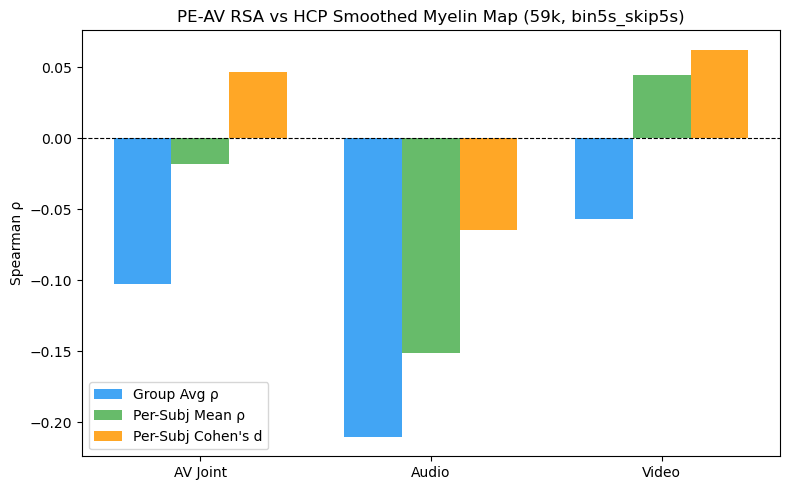

In [5]:
print("Loading/resampling myelin to 59k...")
myelin = load_myelin_59k()
print(f"Myelin: {myelin.shape}, nan={np.isnan(myelin).sum()}\n")

RSA_LABELS = ['Group Avg ρ', 'Per-Subj Mean ρ', "Per-Subj Cohen's d"]
COLORS     = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(MODALITIES))
w = 0.25

for ri, (label, color) in enumerate(zip(RSA_LABELS, COLORS)):
    vals = []
    for mod_code, mod_label in MODALITIES.items():
        grp_rho, ps_rho, ps_d = load_rsa_maps(mod_code)
        rsa_map = [grp_rho, ps_rho, ps_d][ri]
        valid   = ~np.isnan(rsa_map) & ~np.isnan(myelin)
        r, _    = spearmanr(myelin[valid], rsa_map[valid])
        vals.append(r)
        print(f'{mod_label}  {label}: ρ = {r:.3f}')
    ax.bar(x + ri * w, vals, w, label=label, color=color, alpha=0.85)

ax.set_xticks(x + w)
ax.set_xticklabels(list(MODALITIES.values()))
ax.set_ylabel('Spearman ρ')
ax.set_title(f'PE-AV RSA vs HCP Smoothed Myelin Map (59k, {BIN_TAG})')
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.legend()
plt.tight_layout()
plt.show()
